In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [2]:
df = pd.read_csv("Downloads/Downloads-20251229T140614Z-1-001/TNS/UberDataset.csv")
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB
None


In [4]:
print(df.describe())

              MILES
count   1156.000000
mean      21.115398
std      359.299007
min        0.500000
25%        2.900000
50%        6.000000
75%       10.400000
max    12204.700000


In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64


In [6]:
df.columns = df.columns.str.strip().str.lower()

In [7]:
df

,start_date,end_date,category,start,stop,miles,purpose
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [8]:
target_col_name = 'category'
print("\nTarget variable value counts:\n", df[target_col_name].value_counts())


Target variable value counts:
 category
Business    1078
Personal      77
Name: count, dtype: int64


In [9]:
bins = [0, 3, 6, 10]  
labels = ["Low", "Medium", "High"]

target_col = "category"

# Encode categorical features
le = LabelEncoder()

In [10]:
df.columns

Index(['start_date', 'end_date', 'category', 'start', 'stop', 'miles',
       'purpose'],
      dtype='object')

In [11]:
cols = df.select_dtypes(include='object').columns
cols

Index(['start_date', 'end_date', 'category', 'start', 'stop', 'purpose'], dtype='object')

In [12]:
from sklearn.preprocessing import LabelEncoder

df = df.copy()

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [13]:
df.corr()

,start_date,end_date,category,start,stop,miles,purpose
start_date,1.000000,0.997916,0.131512,0.139671,0.142840,0.052865,0.208620
end_date,0.997916,1.000000,0.138543,0.140281,0.140606,0.052867,0.210573
category,0.131512,0.138543,1.000000,0.036576,0.047727,0.220952,0.228887
start,0.139671,0.140281,0.036576,1.000000,0.359185,0.044159,0.119921
stop,0.142840,0.140606,0.047727,0.359185,1.000000,0.046249,0.126072
miles,0.052865,0.052867,0.220952,0.044159,0.046249,1.000000,0.026211
purpose,0.208620,0.210573,0.228887,0.119921,0.126072,0.026211,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

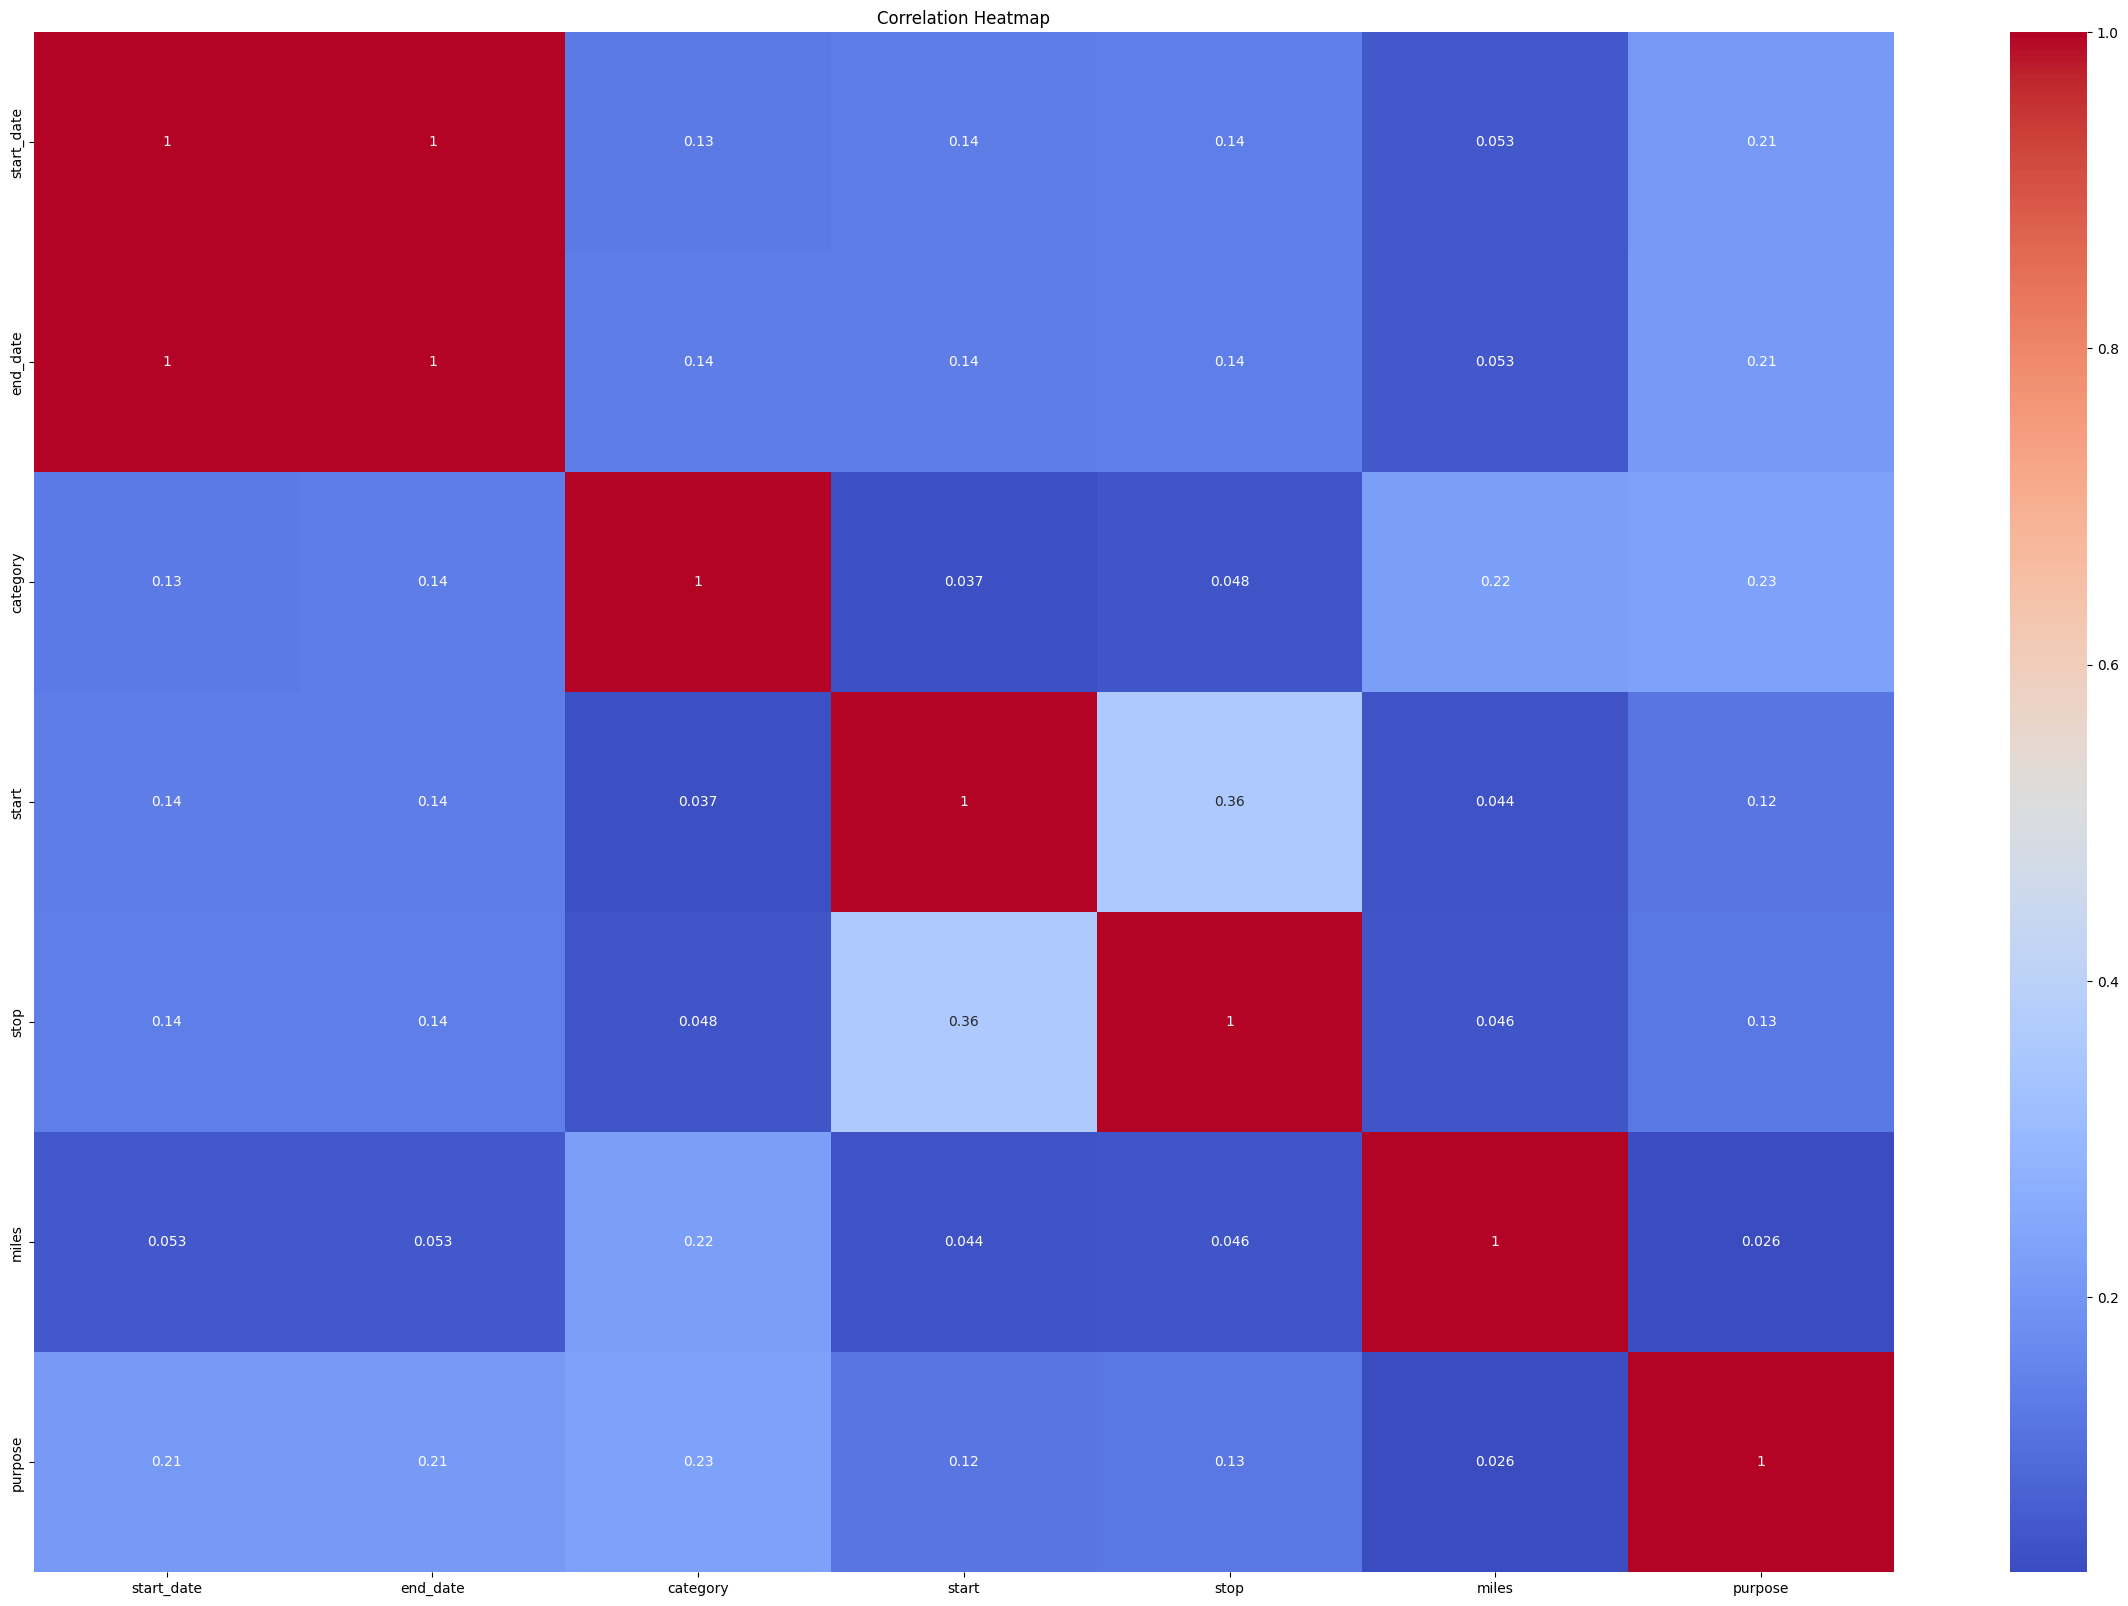

In [14]:
# Correlation Heatmap
plt.figure(figsize=(30, 20))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

In [15]:
# Feature/Target Split
y = df['miles']
X = df.drop(columns='miles')


# Train-Test Split (removed stratify as it's not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
param_grid = {
    'criterion': ['squared_error'],
    'max_depth': [None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_split': 5}


In [30]:
#Train Best Model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [33]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 528.1287030052682
RMSE: 22.981050955194984
R2 Score: -0.2292501612302451


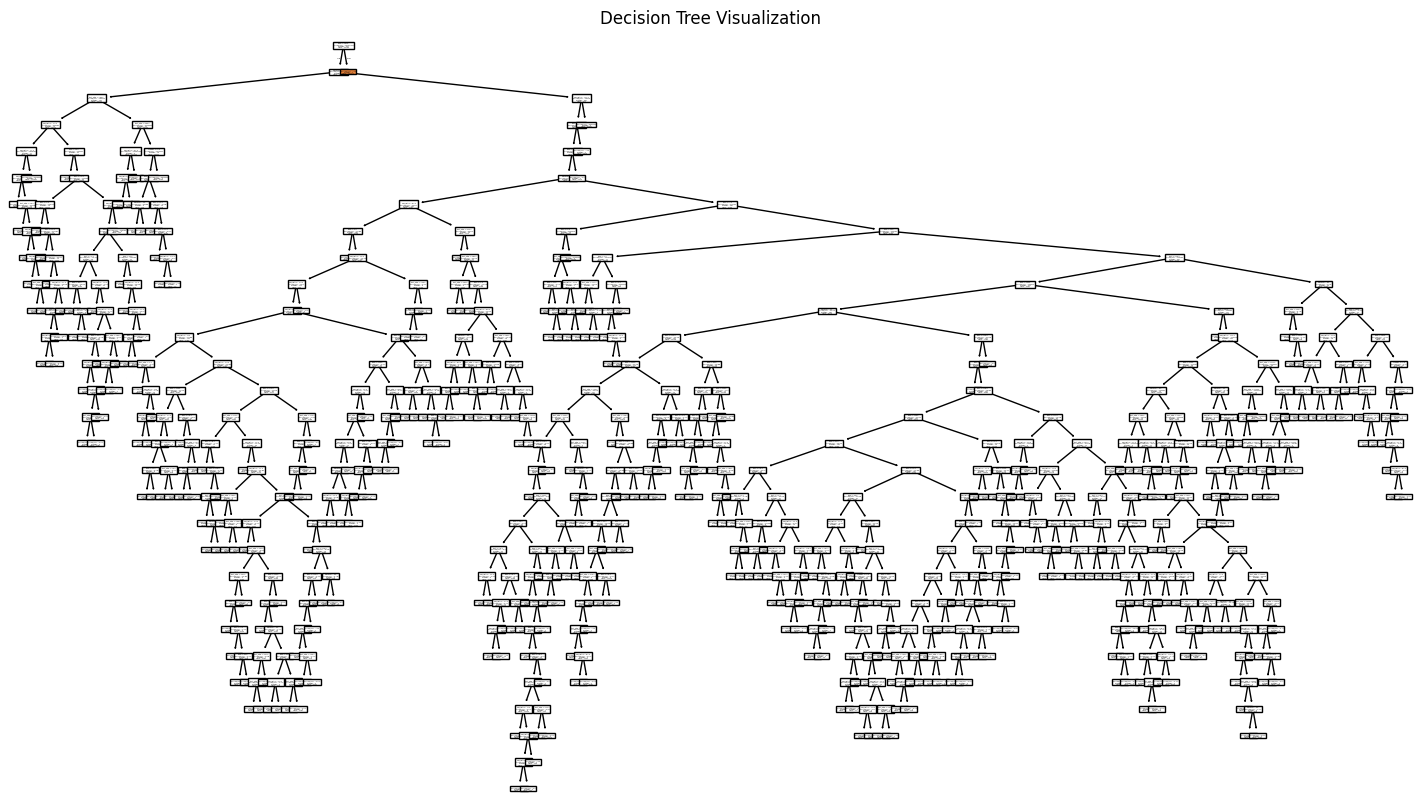

In [27]:
plt.figure(figsize=(18, 10))
plot_tree(best_model, feature_names=X.columns, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

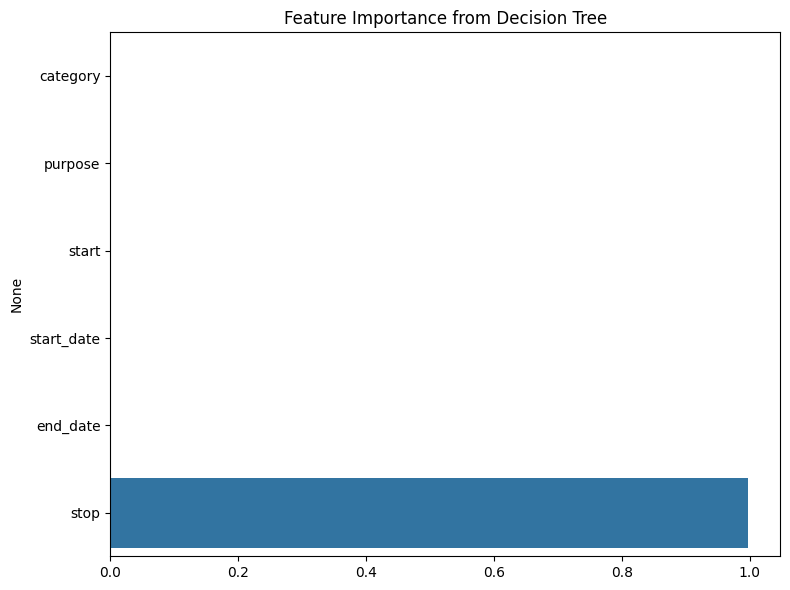

In [34]:
#Feature  Importance
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Decision Tree")
plt.tight_layout()
plt.show()

In [35]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances
# Show hidden output

category      0.000094
purpose       0.000155
start         0.000598
start_date    0.000617
end_date      0.000766
stop          0.997770
dtype: float64

In [42]:
print("\nSummary:")
print(f"Decision Tree trained using best parameters: {grid.best_params_}")
print(f"RMSE after tuning: {rmse:.2f}")
print(f"R2 Score after tuning: {r2:.2f}")
print("Feature importance and tree structure were visualized.")
print("Model is ready for future use.")


Summary:
Decision Tree trained using best parameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_split': 5}
RMSE after tuning: 22.98
R2 Score after tuning: -0.23
Feature importance and tree structure were visualized.
Model is ready for future use.


In [38]:
# Decision Tree Regressor
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Load Dataset
df = pd.read_csv("Downloads/Downloads-20251229T140614Z-1-001/TNS/UberDataset.csv")

# Drop missing values (if any)
df = df.dropna()

# Target column
target_col = "CATEGORY"

# Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Decision Tree Regressor
reg = DecisionTreeRegressor(random_state=42)

# Hyperparameter tuning with GridSearchCV
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["squared_error", "friedman_mse", "absolute_error"]
}

grid_search = GridSearchCV(reg, param_grid, cv=5, scoring="r2")
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [40]:
# Best model
best_reg = grid_search.best_estimator_

# Predictions
y_pred = best_reg.predict(X_test)

# Evaluation
print("Best Parameters:", grid_search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'criterion': 'squared_error', 'max_depth': 3, 'min_samples_split': 2}
R2 Score: 1.0
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0


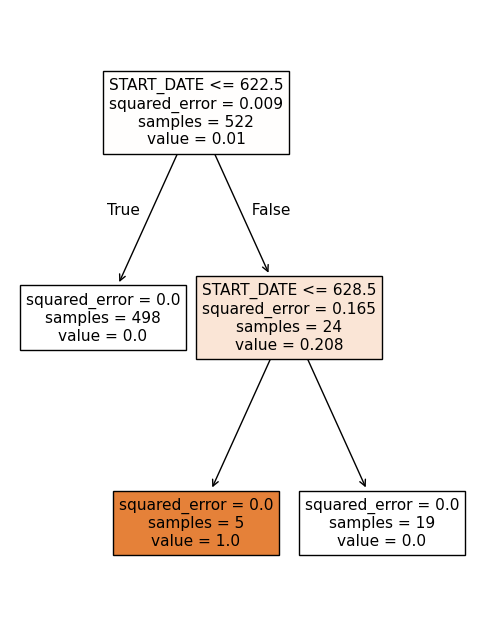

In [41]:
# Plot Decision Tree
plt.figure(figsize=(6, 8))
plot_tree(best_reg, feature_names=X.columns, filled=True)
plt.show()